In [2]:
import sys
import os

# Add the parent directory to Python's path so it can find 'src'
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import matplotlib.pyplot as plt
from src.metrics import offset_report, segmented_report

# Load the newly generated ground truth data
gt_df = pd.read_parquet("../data/processed/ground_truth.parquet")

# Filter for rows where the LLM successfully returned coordinates
valid_gt = gt_df.dropna(subset=["gt_lat", "gt_lon"]).copy()
print(f"Valid ground truth records: {len(valid_gt)}")

Valid ground truth records: 750


In [4]:
baseline_offsets = valid_gt["offset_haversine_m"]
global_report = offset_report(baseline_offsets)

print("=== Global Baseline Offset Report ===")
for metric, value in global_report.items():
    print(f"{metric:>20}: {value}")

=== Global Baseline Offset Report ===
               count: 750
              mean_m: 4.59
            median_m: 0.0
               std_m: 6.69
               p90_m: 16.33
               p95_m: 17.56
               max_m: 42.78
      pct_within_10m: 72.1
      pct_within_25m: 99.7
      pct_within_50m: 100.0
     pct_within_100m: 100.0
     pct_within_250m: 100.0


In [11]:
category_report = segmented_report(
    df=valid_gt, 
    offset_col="offset_haversine_m", 
    segment_col="category_primary", 
    top_n=10
)

print("\nWorst Performing Categories (Median Offset)")
display(category_report[["segment", "n", "median_m", "p90_m", "pct_within_25m"]])
print(valid_gt["offset_haversine_m"].max())
print("is the max offset")


Worst Performing Categories (Median Offset)


,segment,n,median_m,p90_m,pct_within_25m
226,writing_service,1,18.42,18.42,100.0
40,chicken_wings_restaurant,1,18.06,18.06,100.0
41,child_care_and_day_care,1,17.80,17.80,100.0
151,outdoor_gear,3,17.78,18.38,100.0
84,forestry_service,1,17.68,17.68,100.0
121,korean_restaurant,1,17.58,17.58,100.0
48,cosmetic_and_beauty_supplies,1,17.37,17.37,100.0
73,farmers_market,1,16.77,16.77,100.0
33,candle_store,1,16.71,16.71,100.0
94,hair_supply_stores,3,16.65,18.19,100.0


42.7761579774742
is the max offset


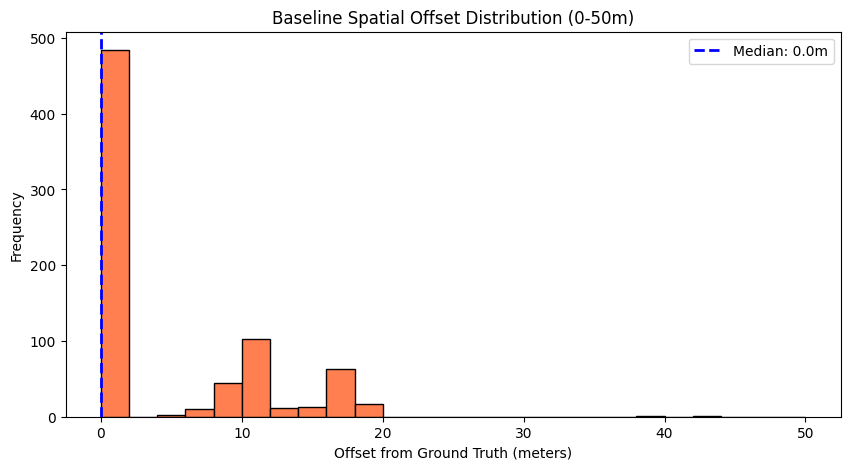

In [12]:
plt.figure(figsize=(10, 5))

plt.hist(baseline_offsets, bins=25, range=(0, 50), color="coral", edgecolor="black")

plt.axvline(global_report["median_m"], color="blue", linestyle="dashed", linewidth=2, 
            label=f"Median: {global_report['median_m']}m")

plt.title("Baseline Spatial Offset Distribution (0-50m)")
plt.xlabel("Offset from Ground Truth (meters)")
plt.ylabel("Frequency")
plt.legend()
plt.show()
